In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("X:\COURS\PYTHON\cybersecurity_intrusion_data.csv")

In [3]:
data

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9532,SID_09533,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9533,SID_09534,380,TCP,3,182.848475,NaN,0.408485,0,Chrome,0,0
9534,SID_09535,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0
9535,SID_09536,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0


# ANALYSE EXPLORATOIRE DES DONNEES ET NETTOYAGE

In [4]:
data.shape

(9537, 11)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   str    
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   str    
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   str    
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   str    
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 819.7 KB


In [6]:
data.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [7]:
data.describe(include=object)

C:\Users\dell\AppData\Local\Temp\ipykernel_7260\3757873171.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=object)


,session_id,protocol_type,encryption_used,browser_type
count,9537,9537,7571,9537
unique,9537,3,2,5
top,SID_00001,TCP,AES,Chrome
freq,1,6624,4706,5137


In [8]:
data["attack_detected"].value_counts() / data.shape[0] * 100

attack_detected
0    55.289923
1    44.710077
Name: count, dtype: float64

In [9]:
data.columns

Index(['session_id', 'network_packet_size', 'protocol_type', 'login_attempts',
       'session_duration', 'encryption_used', 'ip_reputation_score',
       'failed_logins', 'browser_type', 'unusual_time_access',
       'attack_detected'],
      dtype='str')

In [10]:
df = data.copy()

In [11]:
df.drop(columns=["session_id"], inplace=True)

In [12]:
df

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...
9532,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9533,380,TCP,3,182.848475,NaN,0.408485,0,Chrome,0,0
9534,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0
9535,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0


<Axes: xlabel='attack_detected', ylabel='count'>

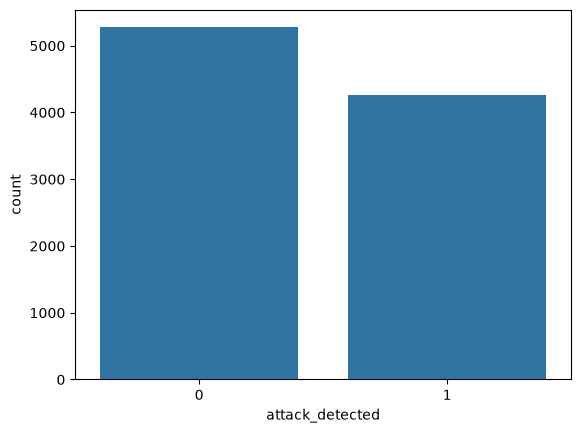

In [13]:
sns.countplot(x="attack_detected",data=df)

In [14]:
df.columns

Index(['network_packet_size', 'protocol_type', 'login_attempts',
       'session_duration', 'encryption_used', 'ip_reputation_score',
       'failed_logins', 'browser_type', 'unusual_time_access',
       'attack_detected'],
      dtype='str')

<Axes: xlabel='network_packet_size', ylabel='Count'>

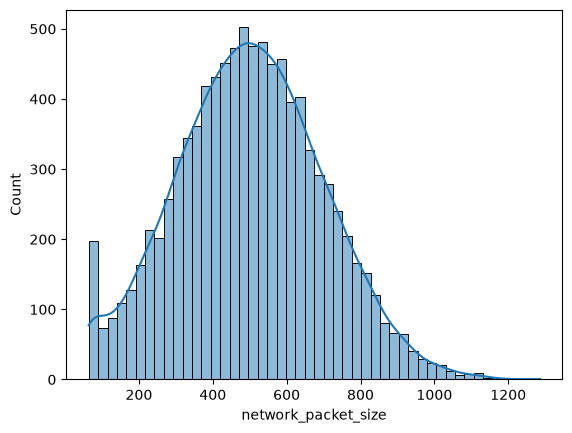

In [15]:
sns.histplot(x="network_packet_size",data=df,kde=True)

In [16]:
df.columns

Index(['network_packet_size', 'protocol_type', 'login_attempts',
       'session_duration', 'encryption_used', 'ip_reputation_score',
       'failed_logins', 'browser_type', 'unusual_time_access',
       'attack_detected'],
      dtype='str')

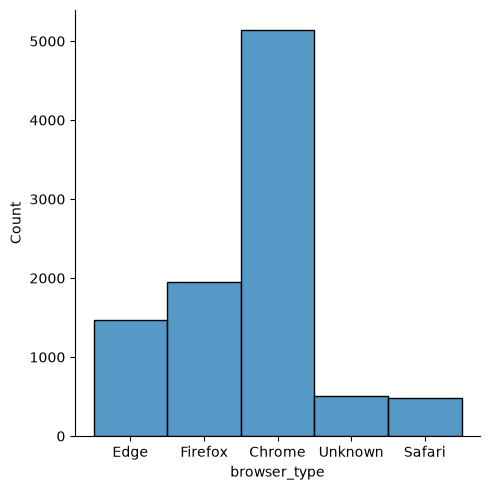

In [17]:
sns.displot(x="browser_type",data=df)

In [18]:
df.drop(columns=["browser_type",'protocol_type','encryption_used',"unusual_time_access"],inplace=True)

In [19]:
df

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,attack_detected
0,599,4,492.983263,0.606818,1,1
1,472,3,1557.996461,0.301569,0,0
2,629,3,75.044262,0.739164,2,1
3,804,4,601.248835,0.123267,0,1
4,453,5,532.540888,0.054874,1,0
...,...,...,...,...,...,...
9532,194,3,226.049889,0.517737,3,1
9533,380,3,182.848475,0.408485,0,0
9534,664,5,35.170248,0.359200,1,0
9535,406,4,86.664703,0.537417,1,0


# SEPARATION ET ENTRAINEMENT

In [20]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.pipeline import make_pipeline

In [21]:
X = df.drop(columns=["attack_detected"])
y = df["attack_detected"]

In [22]:
X

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins
0,599,4,492.983263,0.606818,1
1,472,3,1557.996461,0.301569,0
2,629,3,75.044262,0.739164,2
3,804,4,601.248835,0.123267,0
4,453,5,532.540888,0.054874,1
...,...,...,...,...,...
9532,194,3,226.049889,0.517737,3
9533,380,3,182.848475,0.408485,0
9534,664,5,35.170248,0.359200,1
9535,406,4,86.664703,0.537417,1


In [23]:
y

0       1
1       0
2       1
3       1
4       0
       ..
9532    1
9533    0
9534    0
9535    0
9536    1
Name: attack_detected, Length: 9537, dtype: int64

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [25]:
score = cross_val_score(RandomForestClassifier(), X_train, y_train,cv=5)
score.mean()

np.float64(0.8669537417012225)

In [26]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [27]:
model.score(X_test,y_test)

0.8611111111111112

In [28]:
model.predict_proba(X_test)

array([[0.  , 1.  ],
       [0.  , 1.  ],
       [0.  , 1.  ],
       ...,
       [0.  , 1.  ],
       [0.01, 0.99],
       [0.58, 0.42]], shape=(1908, 2))

In [29]:
pipeline = make_pipeline(StandardScaler(),
                         SVC())

In [30]:
scoreSVC = cross_val_score(pipeline, X_train,y_train,cv=5)
scoreSVC.mean()

np.float64(0.8653810025138045)

In [31]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['network_packet_size','login_attempts','session_duration', 'ip_reputation_score','failed_logins']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [32]:
pipeline.score(X_test, y_test)

0.8569182389937107

# RANDOM FOREST RESTE LE CHOIX IDEAL AU VU DE SA PERFORMANCE LEGEREMENT SUPERIEUR A SVM 

In [33]:
importances = model.feature_importances_

In [34]:
importance_df = pd.DataFrame({
    "feature" : X_train.columns,
    "importance" : importances}).sort_values("importance", ascending=False)
importance_df

,feature,importance
4,failed_logins,0.289037
3,ip_reputation_score,0.258732
1,login_attempts,0.203538
2,session_duration,0.130700
0,network_packet_size,0.117993


# CI-HAUT ON PEUT VOIR L'IMPORTANCE DE CHAQUE VARIABLE DANS RF

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[1042,   13],
       [ 252,  601]])

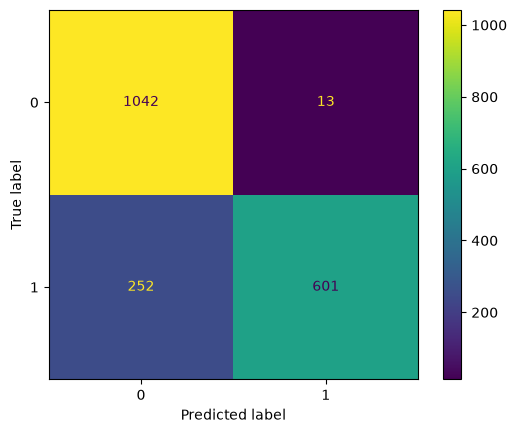

In [36]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [37]:
y.value_counts(normalize=True)

attack_detected
0    0.552899
1    0.447101
Name: proportion, dtype: float64

In [38]:
y_proba = model.predict_proba(X_test)[:,1]
seuil = 0.2

y_pred = (y_proba >= seuil).astype(int)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred)
cm

array([[630, 425],
       [148, 705]])

In [39]:
y_proba[:10]

array([1.  , 1.  , 1.  , 0.2 , 0.1 , 0.34, 1.  , 0.15, 0.31, 0.03])

In [40]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

ModuleNotFoundError: No module named 'imblearn'

In [ ]:
dt = data.copy()
dt["encryption_used"].fillna(dt["encryption_used"].mode()[0],inplace=True)
X = dt.drop(columns=["attack_detected","session_id"])
y = dt["attack_detected"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
dt.columns

In [ ]:
dt.isnull().sum()

In [ ]:
preprocesseur= ColumnTransformer([
    ("chaine", OneHotEncoder(),['encryption_used','browser_type','protocol_type'])],remainder="passthrough")

In [ ]:
rf = make_pipeline(preprocesseur,SMOTE(),
                   XGBClassifier(n_estimators=100,random_state=42))

In [ ]:
rf_score = cross_val_score(rf,X_train, y_train,cv=5)
rf_score.mean()

In [ ]:
rf.fit(X_train,y_train)

In [ ]:
rf.score(X_test, y_test)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# SAUVEGARDE DU MODELE sous format pickle

In [48]:
import joblib

In [ ]:
print("hello")

In [44]:
import sklearn

In [41]:
np.__version__

'2.4.6'

In [42]:
pd.__version__

'3.0.3'

In [45]:
sklearn.__version__

'1.9.0'

In [46]:
import os

In [49]:
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/model.pkl")
os.listdir("models")

['model.pkl']